In [7]:
import urllib.request
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
# Initialize the model
TRAIN = False
PRE_TRAIN = True
if TRAIN:
    model = YOLO('yolo12m.pt') 

    # Finetune the model the model
    results = model.tune(
        data="SKU-110K.yaml", 
        epochs=20,      # Fewer epochs per trial is better for tuning
        iterations=6,  # Number of different hyperparameter combos to try
        optimizer="AdamW", 
        patience=5,
        imgsz=1024,
        batch=4,
        device=0,
        amp=True,        # CRITICAL for V100 speed (Automatic Mixed Precision)
        project='norgesgruppen',
        name='yolo12m_sku110k_v100',

        # --- Data augmentation ---
        degrees=15.0,       # Help with fallen/tilted bags
        perspective=0.001,  # Help with weird camera angles
        hsv_v=0.4,          # Help with fridge lighting wash-out
        mixup=0.15,         # Help with overlapping/crumpled bags
        mosaic=1.0          # (Usually on by default, but crucial for small objects)
    )
else:
    model = YOLO("best.pt")
    if PRE_TRAIN:
        model_finetuned = YOLO("best.pt")

        model_finetuned.train(
            data='data/norgesgruppen.yaml', # The YAML the script created
            epochs=20,                      # You don't need many epochs for fine-tuning
            imgsz=1280,                     # Keep it high
            batch=-1,
            device=0,
            project='norgesgruppen_final',
            name='yolo12m_finetuned',
    
            # --- Fine-Tuning Augmentations ---
            degrees=0.0,        # Turn off heavy rotation
            perspective=0.0,    # Keep shelves straight
            hsv_s=0.7,          # Keep color variance high for fridges
            hsv_v=0.4,          # Keep brightness variance high
            mosaic=1.0,         # Crucial for small object recall
        )


SyntaxError: expected ':' (3728868217.py, line 30)


image 1/1 /Users/runarfosse/Documents/nm-ai-2026/computer-vision/data/train/images/img_00019.jpg: 1536x1152 133 objects, 2570.8ms
Speed: 11.8ms preprocess, 2570.8ms inference, 2.3ms postprocess per image at shape (1, 3, 1536, 1152)
YOLO found 133 objects!


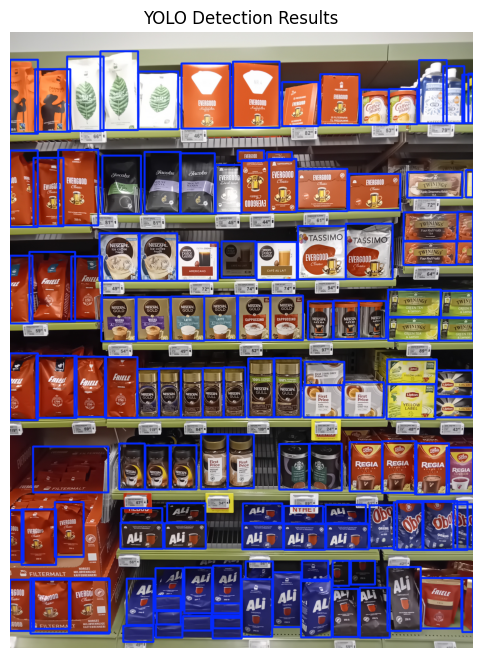

In [ ]:
# Run inference. 
image_path = "data/train/images/img_00019.jpg"
results = model(image_path, conf=0.1, iou=0.5, max_det=1000, agnostic_nms=True, imgsz=1536)

# Extract the first result (since we only passed one image)
result = results[0]
print(f"YOLO found {len(result.boxes)} objects!")

# .plot() returns a numpy array (BGR format for OpenCV)
annotated_img = result.plot(labels=False)

# Convert BGR (OpenCV standard) to RGB (Matplotlib standard)
annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(12, 8))
plt.imshow(annotated_img_rgb)
plt.axis('off')
plt.title("YOLO Detection Results")
plt.show()

In [ ]:
# Run inference. 
image_path = "data/train/images/img_00019.jpg"
results = model_finetuned(image_path, conf=0.1, iou=0.5, max_det=1000, agnostic_nms=True, imgsz=1536)

# Extract the first result (since we only passed one image)
result = results[0]
print(f"YOLO found {len(result.boxes)} objects!")

# .plot() returns a numpy array (BGR format for OpenCV)
annotated_img = result.plot(labels=False)

# Convert BGR (OpenCV standard) to RGB (Matplotlib standard)
annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(12, 8))
plt.imshow(annotated_img_rgb)
plt.axis('off')
plt.title("YOLO Detection Results")
plt.show()

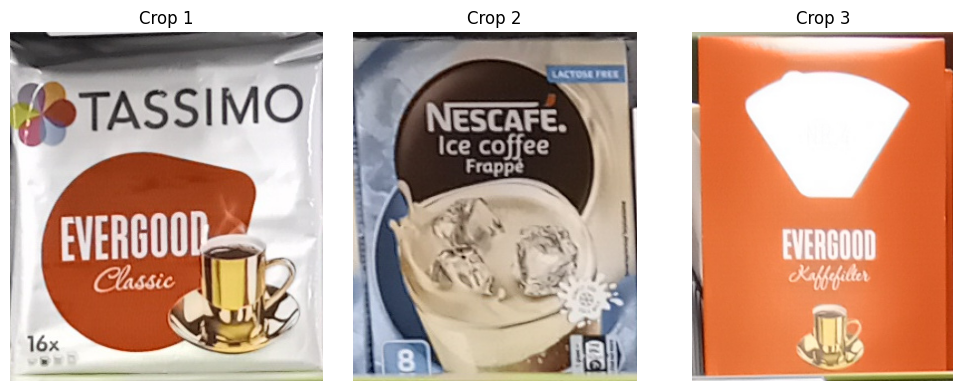

In [ ]:
# Load the original image using OpenCV
original_img = cv2.imread(image_path)
original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Extract the bounding boxes as a numpy array
# Format is[x_min, y_min, x_max, y_max]
boxes = result.boxes.xyxy.cpu().numpy()

# Let's plot the original image alongside the first 3 cropped products
num_crops_to_show = min(3, len(boxes))
fig, axes = plt.subplots(1, num_crops_to_show, figsize=(10, 4))

for i in range(num_crops_to_show):
    # Get coordinates and convert to integers
    x1, y1, x2, y2 = map(int, boxes[i])
    
    # Crop the image array: image[y_start:y_end, x_start:x_end]
    cropped_product = original_img_rgb[y1:y2, x1:x2]
    
    # Display the crop
    ax = axes[i] if num_crops_to_show > 1 else axes
    ax.imshow(cropped_product)
    ax.set_title(f"Crop {i+1}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# Image to test (you can change this to any image in your dataset)
image_path = "data/train/images/img_00019.jpg"
# Look for the label created by our conversion script
label_path = Path("data/train/labels") / (Path(image_path).stem + ".txt")

# 1. Run inference on both models
print("Running inference on SKU-110k model...")
res_sku = model(image_path, conf=0.1, iou=0.5, max_det=1000, agnostic_nms=True, imgsz=1536)[0]
img_sku = cv2.cvtColor(res_sku.plot(labels=False), cv2.COLOR_BGR2RGB)

print("Running inference on Finetuned model...")
res_finetuned = model_finetuned(image_path, conf=0.1, iou=0.5, max_det=1000, agnostic_nms=True, imgsz=1536)[0]
img_finetuned = cv2.cvtColor(res_finetuned.plot(labels=False), cv2.COLOR_BGR2RGB)

# 2. Load Ground Truth Image
img_gt = cv2.imread(image_path)
img_gt = cv2.cvtColor(img_gt, cv2.COLOR_BGR2RGB)
img_h, img_w, _ = img_gt.shape

# 3. Setup the 1x3 Subplot
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# Subplot 1: SKU-110k
axes[0].imshow(img_sku)
axes[0].set_title(f"Stage 1: SKU-110k ({len(res_sku.boxes)} objects)", fontsize=16)
axes[0].axis('off')

# Subplot 2: Finetuned
axes[1].imshow(img_finetuned)
axes[1].set_title(f"Stage 2: NorgesGruppen Finetuned ({len(res_finetuned.boxes)} objects)", fontsize=16)
axes[1].axis('off')

# Subplot 3: Ground Truth
axes[2].imshow(img_gt)
if label_path.exists():
    with open(label_path, 'r') as f:
        lines = f.readlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            _, x_c, y_c, w, h = map(float, parts)
            box_w = w * img_w
            box_h = h * img_h
            x_min = (x_c * img_w) - (box_w / 2)
            y_min = (y_c * img_h) - (box_h / 2)
            
            # Draw green ground truth boxes
            rect = patches.Rectangle((x_min, y_min), box_w, box_h, linewidth=2, edgecolor='lime', facecolor='none')
            axes[2].add_patch(rect)
    axes[2].set_title(f"Ground Truth Labels ({len(lines)} objects)", fontsize=16)
else:
    axes[2].set_title("Ground Truth Labels (No label file found)", fontsize=16)
axes[2].axis('off')

plt.tight_layout()
plt.show()